In [32]:
import pandas as pd 
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import datetime as dt 
import importlib

importlib.reload(helpers)
import helpers
from helpers import data_extraction,montecarlosims, ConfigLoader


# get the data of my portfolio 




In [22]:
# read config file
config=ConfigLoader.configload()
config


{'stocks': ['PLTR',
  'AAPL',
  'MSFT',
  'NVDA',
  'BMNR',
  'BABA',
  'SOFI',
  'AVPT',
  'CRM',
  'GOOG',
  'DKNG',
  'LMT',
  'NOC',
  'NFLX',
  'PG',
  'UNH',
  'ADBE'],
 'weigths': [0.43,
  0.06,
  0.07,
  0.06,
  0.02,
  0.04,
  0.03,
  0.03,
  0.04,
  0.05,
  0.02,
  0.005,
  0.005,
  0.04,
  0.05,
  0.05,
  0.01]}

In [24]:
# get the data of my portfolio 
end=dt.datetime.now()
start=end-dt.timedelta(days=1800)
meanReturns,Covmatrix=data_extraction.get_data(config['stocks'],start,end)


[*********************100%***********************]  17 of 17 completed


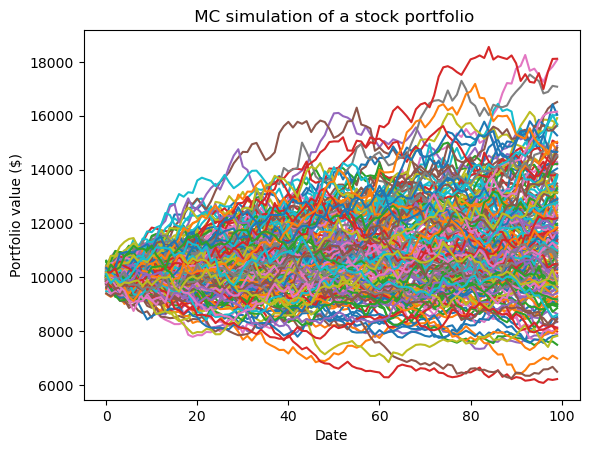

Expected return: 11453.351428109976
Median return: 11244.900427444107
Loss probability: 0.285


In [33]:
# run monte carlo sims 

montecarlosims.monte_carlo(100,Covmatrix,200,meanReturns,config['weigths'],10000)

We wish to find out why the loss probability is so high at 28.5%?

We will try to delve in deeper into understanding how we can reduce our downside

1) Whether the loss probability is driven by systematic risk (interest rate etc)
2) How much unsystematic risk is my portfolio exposed?

Hypothesis: Alot of Tech stocks hence, very little diversification and hence, high unsystematic risk



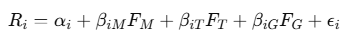

Running of Factor models:

We have decided to run factor models using factors:

- US 500 (market) -> This is market risk encapsulating economy wide shocks, interest rate changes and macro changes
- Tech factor (XLK) -> This is with regards to me being heavy on tech stocks. Hence, we are trying to segregate sector risk from market risk
- HML -> Value vs growth spread. This captures discount rate sensitivity and duration risk 
- SMB -> Size of company. Small cap premium or high business risk

